In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm, chi2

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Данные задачи Б (90 значений)
data_B_raw = """
109,42 92,59 119,53 103,76 101,44 91,56 111,74 102,48 92,21
99,46 109,18 99,83 99,14 101,31 96,71 95,22 90,72 93,69
98,72 82,92 101,83 115,43 98,13 117,48 117,92 99,41 113,81
100,61 104,72 89,11 95,59 95,19 113,46 89,88 100,54 101,94
105,84 102,65 114,57 101,74 108,83 87,57 101,19 95,69 91,44
87,86 98,34 97,15 103,55 92,14 112,04 88,44 98,49 100,04
98,54 110,62 112,23 101,63 100,59 88,29 109,58 107,14 107,21
91,11 116,73 101,95 111,50 101,52 101,83 115,43 100,31 112,57
100,42 89,22 94,54 102,23 108,99 104,81 90,85 100,61 104,72
107,57 113,61 108,12 107,38 101,38 99,22 110,24 99,14 101,31
"""

# Преобразуем в массив чисел (заменяем запятую на точку)
data_B = np.array([float(x.replace(',', '.')) for x in data_B_raw.split()])
n_B = len(data_B)

print(f"Объём выборки: {n_B}")
print(f"Первые 10 значений: {data_B[:10]}")

Объём выборки: 90
Первые 10 значений: [109.42  92.59 119.53 103.76 101.44  91.56 111.74 102.48  92.21  99.46]


In [3]:
# Вычисление статистик
mean_B = np.mean(data_B)
var_B = np.var(data_B, ddof=1)   # несмещённая дисперсия
std_B = np.std(data_B, ddof=1)   # несмещённое СКО
range_B = np.ptp(data_B)          # размах (max - min)
min_B = np.min(data_B)
max_B = np.max(data_B)

# Вывод результатов
print("=" * 50)
print("Пункт 1. Основные статистики")
print("=" * 50)
print(f"Выборочное среднее (x̄):                 {mean_B:.4f}")
print(f"Выборочная дисперсия (s²):              {var_B:.4f}")
print(f"Среднеквадратическое отклонение (s):    {std_B:.4f}")
print(f"Размах (R):                             {range_B:.4f}")
print(f"Минимум (min):                          {min_B:.4f}")
print(f"Максимум (max):                         {max_B:.4f}")

Пункт 1. Основные статистики
Выборочное среднее (x̄):                 101.8599
Выборочная дисперсия (s²):              67.4848
Среднеквадратическое отклонение (s):    8.2149
Размах (R):                             36.6100
Минимум (min):                          82.9200
Максимум (max):                         119.5300


In [4]:
# Доверительные интервалы для разных надёжностей
conf_levels = [0.95, 0.99, 0.999]

print("=" * 50)
print("Пункт 2. Доверительные интервалы для математического ожидания")
print("=" * 50)

for conf in conf_levels:
    alpha = 1 - conf
    t_crit = t.ppf(1 - alpha/2, df=n_B-1)
    margin = t_crit * std_B / np.sqrt(n_B)
    ci_lower = mean_B - margin
    ci_upper = mean_B + margin
    
    print(f"\nНадёжность {conf*100}% (α = {alpha}):")
    print(f"  t(α/2, n-1) = {t_crit:.4f}")
    print(f"  Погрешность Δ = {margin:.4f}")
    print(f"  Доверительный интервал: [{ci_lower:.4f}; {ci_upper:.4f}]")

Пункт 2. Доверительные интервалы для математического ожидания

Надёжность 95.0% (α = 0.050000000000000044):
  t(α/2, n-1) = 1.9870
  Погрешность Δ = 1.7206
  Доверительный интервал: [100.1393; 103.5805]

Надёжность 99.0% (α = 0.010000000000000009):
  t(α/2, n-1) = 2.6322
  Погрешность Δ = 2.2793
  Доверительный интервал: [99.5806; 104.1392]

Надёжность 99.9% (α = 0.0010000000000000009):
  t(α/2, n-1) = 3.4032
  Погрешность Δ = 2.9469
  Доверительный интервал: [98.9129; 104.8068]


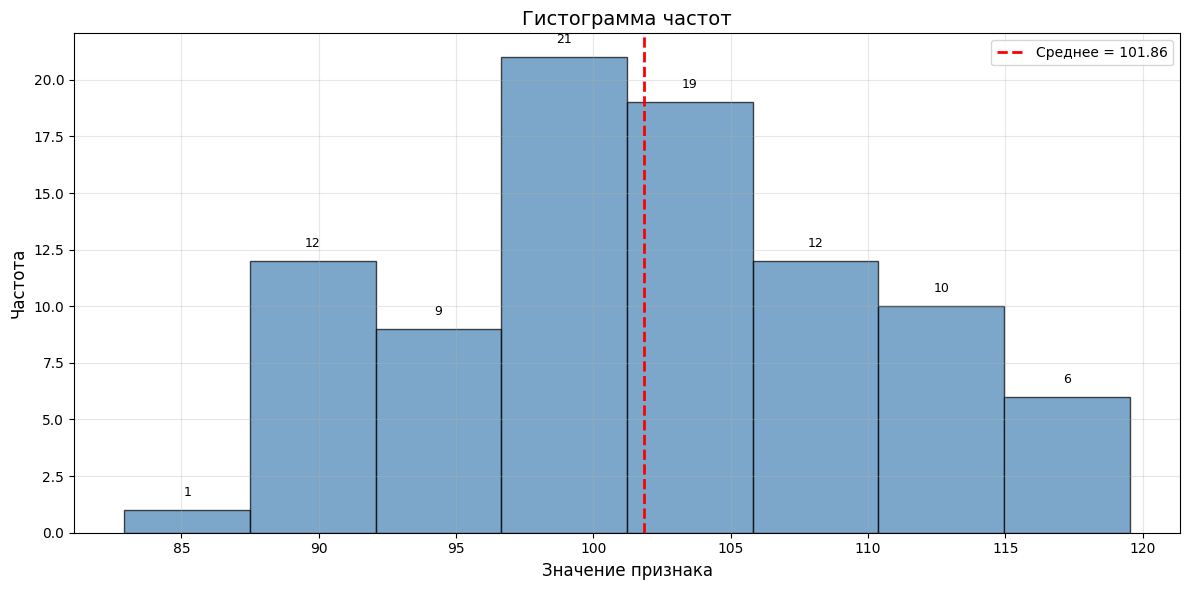

Количество интервалов (по правилу Стёрджеса): 8
Частоты по интервалам: [ 1 12  9 21 19 12 10  6]


In [5]:
# Построение гистограммы
plt.figure(figsize=(12, 6))

# Количество интервалов по правилу Стёрджеса
k = int(np.ceil(np.log2(n_B) + 1))

counts, bins, patches = plt.hist(data_B, bins=k, edgecolor='black', alpha=0.7, color='steelblue')

plt.title('Гистограмма частот', fontsize=14)
plt.xlabel('Значение признака', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(alpha=0.3)
plt.axvline(mean_B, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_B:.2f}')
plt.legend()

# Добавим подписи частот на столбцах
for i, (count, bin_edge) in enumerate(zip(counts, bins[:-1])):
    if count > 0:
        plt.text(bin_edge + (bins[1]-bins[0])/2, count + 0.5, str(int(count)), 
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Количество интервалов (по правилу Стёрджеса): {k}")
print(f"Частоты по интервалам: {counts.astype(int)}")

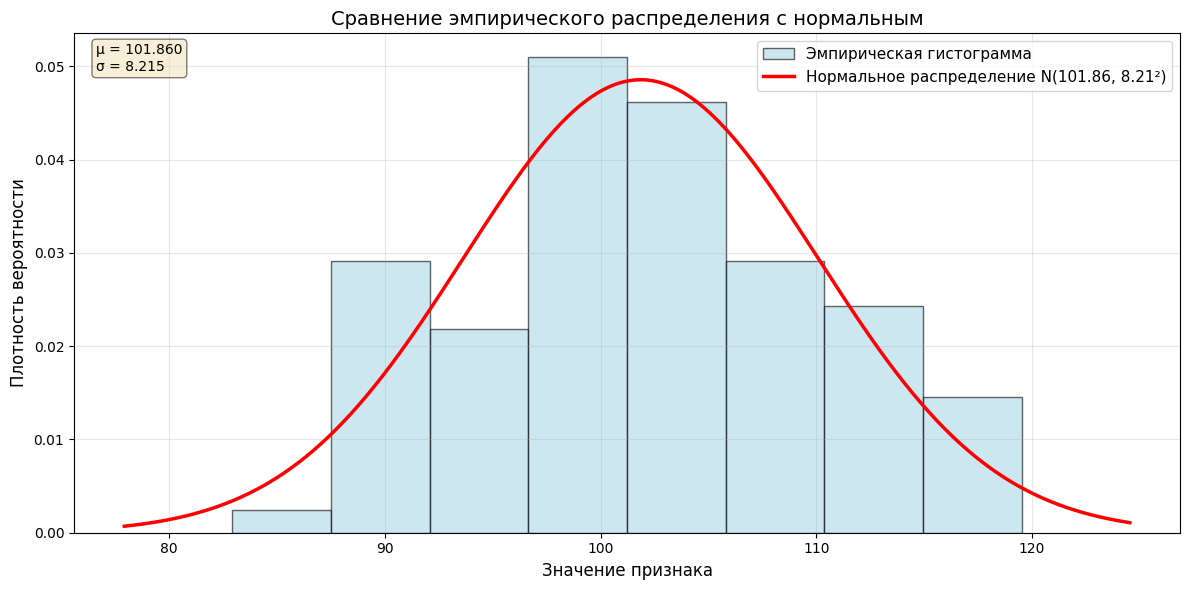

In [6]:
# Построение гистограммы в нормированном виде и теоретической кривой
plt.figure(figsize=(12, 6))

# Нормированная гистограмма (плотность)
counts_norm, bins_norm, patches = plt.hist(data_B, bins=k, density=True, 
                                            edgecolor='black', alpha=0.6, 
                                            color='lightblue', label='Эмпирическая гистограмма')

# Теоретическая плотность нормального распределения
x_norm = np.linspace(min_B - 5, max_B + 5, 500)
pdf_norm = norm.pdf(x_norm, mean_B, std_B)
plt.plot(x_norm, pdf_norm, 'r-', linewidth=2.5, label=f'Нормальное распределение N({mean_B:.2f}, {std_B:.2f}²)')

plt.title('Сравнение эмпирического распределения с нормальным', fontsize=14)
plt.xlabel('Значение признака', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Добавим легенду с параметрами
plt.text(0.02, 0.98, f'μ = {mean_B:.3f}\nσ = {std_B:.3f}', 
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

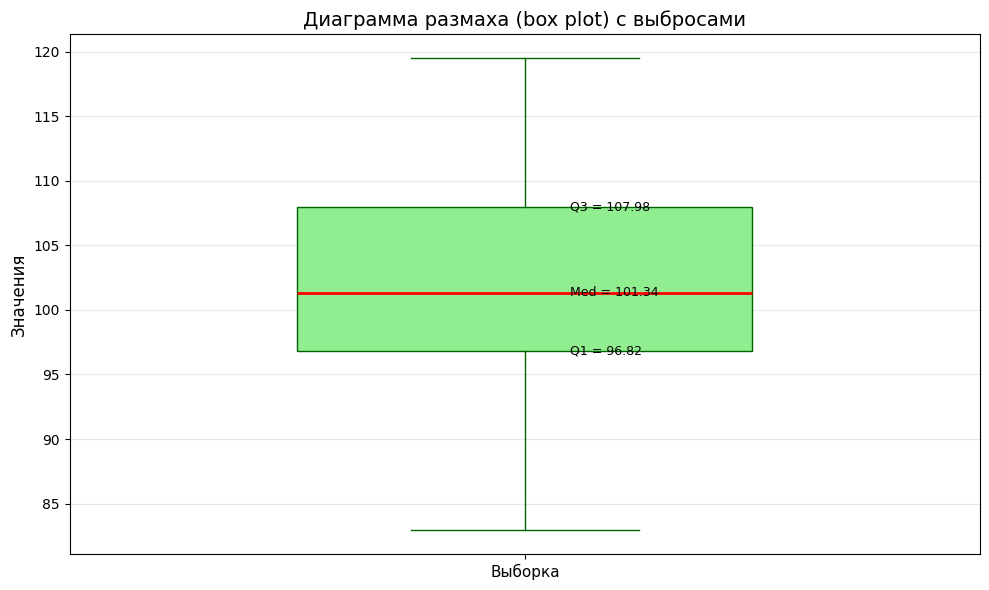

Статистики для блочной диаграммы:
Минимум (без учёта выбросов): 82.9200
Первый квартиль (Q1):          96.8200
Медиана (Q2):                  101.3450
Третий квартиль (Q3):          107.9825
Максимум (без учёта выбросов): 119.5300
Межквартильный размах (IQR):   11.1625

Выбросы не обнаружены


In [7]:
# Создание блочной диаграммы
plt.figure(figsize=(10, 6))

# boxplot с дополнительными параметрами
box = plt.boxplot(data_B, vert=True, patch_artist=True, widths=0.5)

# Настройка цветов
box['boxes'][0].set_facecolor('lightgreen')
box['boxes'][0].set_edgecolor('darkgreen')
box['whiskers'][0].set_color('darkgreen')
box['whiskers'][1].set_color('darkgreen')
box['caps'][0].set_color('darkgreen')
box['caps'][1].set_color('darkgreen')
box['medians'][0].set_color('red')
box['medians'][0].set_linewidth(2)

plt.title('Диаграмма размаха (box plot) с выбросами', fontsize=14)
plt.ylabel('Значения', fontsize=12)
plt.xticks([1], ['Выборка'], fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Добавим подписи квартилей
q1 = np.percentile(data_B, 25)
q2 = np.median(data_B)
q3 = np.percentile(data_B, 75)
iqr = q3 - q1
lower_whisker = max(min_B, q1 - 1.5 * iqr)
upper_whisker = min(max_B, q3 + 1.5 * iqr)

plt.text(1.05, q1, f'Q1 = {q1:.2f}', va='center', fontsize=9)
plt.text(1.05, q2, f'Med = {q2:.2f}', va='center', fontsize=9)
plt.text(1.05, q3, f'Q3 = {q3:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Вывод статистик для box plot
print("=" * 50)
print("Статистики для блочной диаграммы:")
print("=" * 50)
print(f"Минимум (без учёта выбросов): {lower_whisker:.4f}")
print(f"Первый квартиль (Q1):          {q1:.4f}")
print(f"Медиана (Q2):                  {q2:.4f}")
print(f"Третий квартиль (Q3):          {q3:.4f}")
print(f"Максимум (без учёта выбросов): {upper_whisker:.4f}")
print(f"Межквартильный размах (IQR):   {iqr:.4f}")

# Поиск выбросов
outliers = data_B[(data_B < q1 - 1.5 * iqr) | (data_B > q3 + 1.5 * iqr)]
if len(outliers) > 0:
    print(f"\nОбнаружены выбросы ({len(outliers)} шт.): {np.sort(outliers)}")
else:
    print("\nВыбросы не обнаружены")

In [8]:
print("=" * 60)
print("Пункт 6. Критерий согласия Пирсона (χ²) для проверки нормальности")
print("=" * 60)

# Количество интервалов
k = int(np.ceil(np.log2(n_B) + 1))
print(f"\n1. Количество интервалов (правило Стёрджеса): k = {k}")

# Построение интервалов
hist_counts, bin_edges = np.histogram(data_B, bins=k)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print(f"   Фактические частоты: {hist_counts}")

# Ожидаемые вероятности и частоты по нормальному закону
expected_probs = np.diff(norm.cdf(bin_edges, mean_B, std_B))
expected_counts = expected_probs * n_B

print(f"   Ожидаемые частоты (норм.): {expected_counts.round(2)}")

# Объединение интервалов с ожидаемой частотой < 5
merged_counts = []
merged_expected = []
temp_count = 0
temp_expected = 0

for i in range(len(hist_counts)):
    temp_count += hist_counts[i]
    temp_expected += expected_counts[i]
    
    if temp_expected >= 5 or i == len(hist_counts) - 1:
        merged_counts.append(temp_count)
        merged_expected.append(temp_expected)
        temp_count = 0
        temp_expected = 0

print(f"\n2. После объединения интервалов:")
print(f"   Объединённые частоты: {merged_counts}")
print(f"   Ожидаемые частоты:    {[round(x, 2) for x in merged_expected]}")

# Вычисление статистики χ²
chi2_stat = 0
for i in range(len(merged_counts)):
    chi2_stat += (merged_counts[i] - merged_expected[i]) ** 2 / merged_expected[i]

# Степени свободы: (m - 1 - r), где r=2 (оценки μ и σ)
df = len(merged_counts) - 1 - 2
df = max(1, df)  # защита от отрицательных степеней

# Критическое значение
critical = chi2.ppf(0.95, df)
p_value = 1 - chi2.cdf(chi2_stat, df)

print(f"\n3. Расчёт статистики:")
print(f"   χ²_набл = {chi2_stat:.4f}")
print(f"   Число степеней свободы: df = {df}")
print(f"   Критическое значение (α=0.05): χ²_крит = {critical:.4f}")
print(f"   p-value = {p_value:.4f}")

print(f"\n4. Вывод:")
print(f"   χ²_набл ({chi2_stat:.4f}) {'>' if chi2_stat > critical else '<'} χ²_крит ({critical:.4f})")

if chi2_stat < critical:
    print("   → НЕТ оснований отвергнуть H₀.")
    print("   → Распределение генеральной совокупности НЕ ПРОТИВОРЕЧИТ нормальному (на уровне значимости 0.05).")
else:
    print("   → H₀ ОТВЕРГАЕТСЯ.")
    print("   → Распределение генеральной совокупности ЗНАЧИМО ОТЛИЧАЕТСЯ от нормального (на уровне значимости 0.05).")

Пункт 6. Критерий согласия Пирсона (χ²) для проверки нормальности

1. Количество интервалов (правило Стёрджеса): k = 8
   Фактические частоты: [ 1 12  9 21 19 12 10  6]
   Ожидаемые частоты (норм.): [ 2.67  6.89 13.16 18.56 19.36 14.92  8.5   3.58]

2. После объединения интервалов:
   Объединённые частоты: [np.int64(13), np.int64(9), np.int64(21), np.int64(19), np.int64(12), np.int64(10), np.int64(6)]
   Ожидаемые частоты:    [np.float64(9.56), np.float64(13.16), np.float64(18.56), np.float64(19.36), np.float64(14.92), np.float64(8.5), np.float64(3.58)]

3. Расчёт статистики:
   χ²_набл = 5.3599
   Число степеней свободы: df = 4
   Критическое значение (α=0.05): χ²_крит = 9.4877
   p-value = 0.2523

4. Вывод:
   χ²_набл (5.3599) < χ²_крит (9.4877)
   → НЕТ оснований отвергнуть H₀.
   → Распределение генеральной совокупности НЕ ПРОТИВОРЕЧИТ нормальному (на уровне значимости 0.05).


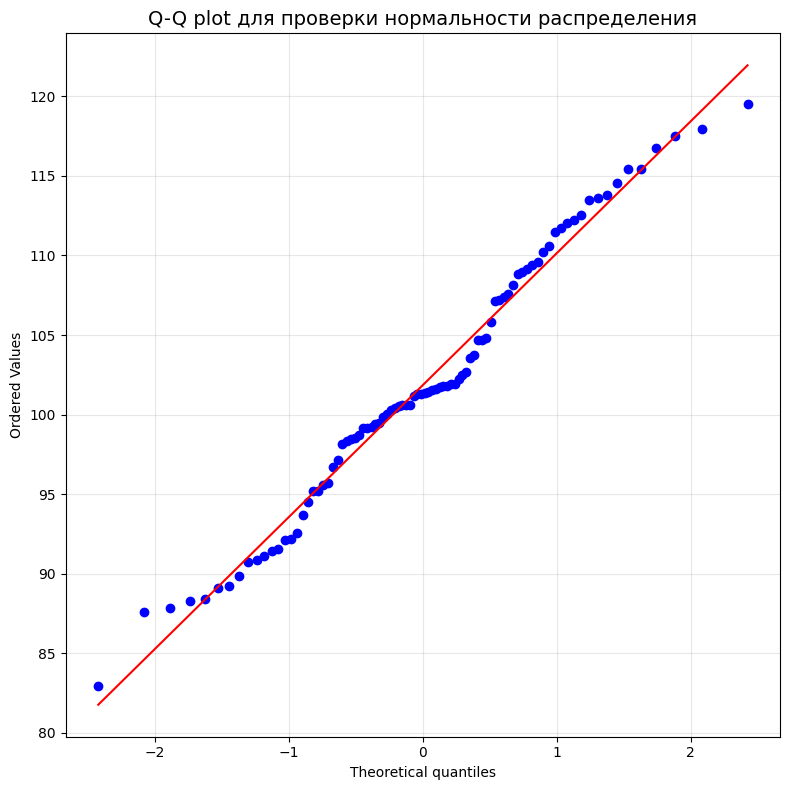

Коэффициент корреляции в Q-Q plot: 0.9916
(Чем ближе к 1, тем ближе распределение к нормальному)


In [9]:
# Q-Q plot для визуальной проверки нормальности
from scipy import stats

plt.figure(figsize=(8, 8))
stats.probplot(data_B, dist="norm", plot=plt)
plt.title('Q-Q plot для проверки нормальности распределения', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Коэффициент корреляции в Q-Q plot
# Чем ближе к 1, тем ближе к нормальному распределению
qq_corr = np.corrcoef(np.sort(data_B), stats.norm.ppf((np.arange(n_B) + 0.5) / n_B))[0, 1]
print(f"Коэффициент корреляции в Q-Q plot: {qq_corr:.4f}")
print("(Чем ближе к 1, тем ближе распределение к нормальному)")